In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


In [7]:
#cargar el dataset
df = pd.read_csv("ventas_ml_clase2.csv")
df.head()

,marketing,precio,temporada,tienda,canal,ventas
0,5548.49,25.74,2,Sur,Tienda,461.70
1,3128.03,31.60,3,Occidente,Tienda,229.12
2,6350.81,37.94,3,Centro,Tienda,397.16
3,6693.02,34.28,3,Norte,Tienda,458.31
4,1488.14,30.45,1,Occidente,Tienda,197.70


In [8]:
print(f"filas: {df.shape[0]}, columnas: {df.shape[1]}")
print("")

print("Tipos de datos:")
for col, type in df.dtypes.items():
    print(f"{col:12s} {type}")
    


filas: 1200, columnas: 6

Tipos de datos:
marketing    float64
precio       float64
temporada    int64
tienda       str
canal        str
ventas       float64


In [9]:
df.describe(include="all").transpose().head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketing,1200.0,NaN,NaN,NaN,4961.787167,1768.35789,0.0,3772.115,5006.215,6107.785,10721.94
precio,1200.0,NaN,NaN,NaN,34.560042,7.154758,13.55,29.915,34.91,39.245,55.4
temporada,1200.0,NaN,NaN,NaN,2.5125,1.112449,1.0,2.0,3.0,3.0,4.0
tienda,1200,5,Norte,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1200,3,Tienda,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#predecir las ventas usando variables: marketing, precio, temporada, tienda, canal
x= df[["marketing", "precio", "temporada", "tienda", "canal"]]
y = df["ventas"]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas, {X_train.shape[0]/len(df)*100:.0f}% del total")
print(f"Datos de prueba: {X_test.shape[0]} filas, {X_test.shape[0]/len(df)*100:.0f}% del total")


Datos de entrenamiento: 960 filas, 80% del total
Datos de prueba: 240 filas, 20% del total


In [11]:
numeric_features = ["marketing", "precio", "temporada"]
categorical_features = ["tienda", "canal"]

preprocess = ColumnTransformer(
    transformers=(
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    )
)

model = LinearRegression()

pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [12]:
pipe.fit(X_train, y_train) #entrenar el modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [16]:
#generar predicciones con los datos de prueba
y_pred = pipe.predict(X_test)  

mae = mean_absolute_error(y_test, y_pred) #error absoluto medio
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #raiz del error cuadratico promedio
r2 = r2_score(y_test, y_pred) #R2: proporción de la varianza explicada por el modelo

media_ventas = y_test.mean() #promedio de ventas reales en el conjunto de prueba

print(f"MAE(Error absoluto medio): {mae:.2f}")
print(f"RMSE(Raíz del error cuadrático medio): {rmse:.2f}")
print(f"R2 (Proporción de varianza explicada): {r2:.4f}({r2*100:.2f}% )")

print("=" * 50)

print("Media de ventas reales:", f"${media_ventas:.2f}")
print("Error relativo (MAE/media):", f"{(mae/media_ventas)*100:.1f}%")

print("=" * 50)
print("interpretacion de las metricas:")
print(f"en promedio, el modelo se equivoca en ${mae:.2f} por prediccion.")
print(f"esto representa un {(mae/media_ventas)*100:.1f}% del promedio de ventas")
print(f"el modelo explica el {r2*100:.1f}% de la variabilidad en las ventas, lo cual es bastante bueno para un modelo simple")
print(f"el {(1-r2)*100:.1f}% restante se debe a factores no incluidos en el modelo")

if r2 >= 0.8:
    print("valoracion: buen ajuste para un modelo lineal")
elif r2 >= 0.5:
    print("valoracion: ajuste moderado, hay espacio para mejorar con modelos")
else:
    print("valoracion: ajuste bajo, se recomienda revisar las variables o probar otros modelos")



MAE(Error absoluto medio): 36.03
RMSE(Raíz del error cuadrático medio): 44.90
R2 (Proporción de varianza explicada): 0.6589(65.89% )
Media de ventas reales: $386.94
Error relativo (MAE/media): 9.3%
interpretacion de las metricas:
en promedio, el modelo se equivoca en $36.03 por prediccion.
esto representa un 9.3% del promedio de ventas
el modelo explica el 65.9% de la variabilidad en las ventas, lo cual es bastante bueno para un modelo simple
el 34.1% restante se debe a factores no incluidos en el modelo
valoracion: ajuste moderado, hay espacio para mejorar con modelos


In [19]:
import matplotlib.pyplot as plt

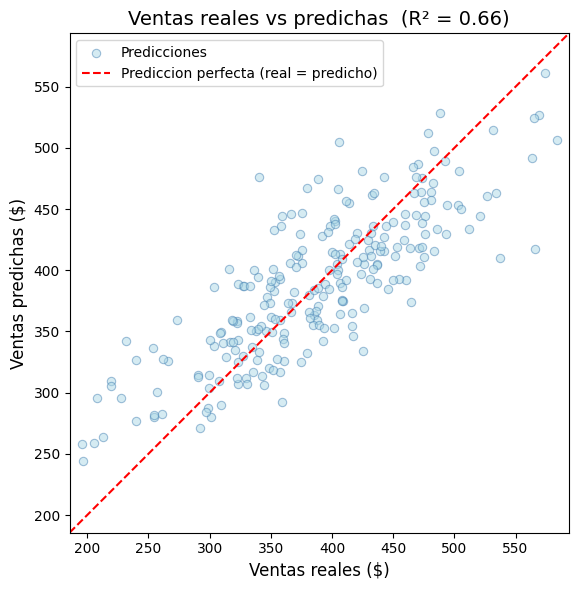

In [20]:
# --- Gráfica de Ventas Reales vs Predichas con línea de tendencia ---
fig, ax = plt.subplots(figsize=(8, 6))

# Cada punto es una observación del set de prueba
# Eje X = venta real, Eje Y = venta predicha por el modelo
ax.scatter(y_test, y_pred, alpha=0.5, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Predicciones")

# Línea de predicción perfecta (donde real = predicho)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
limite_min = min(y_test.min(), y_pred.min()) - 10
limite_max = max(y_test.max(), y_pred.max()) + 10
ax.plot([limite_min, limite_max], [limite_min, limite_max],
        color="red", linestyle="--", linewidth=1.5,
        label="Prediccion perfecta (real = predicho)")

# Etiquetas y título
ax.set_xlabel("Ventas reales ($)", fontsize=12)
ax.set_ylabel("Ventas predichas ($)", fontsize=12)
ax.set_title(f"Ventas reales vs predichas  (R² = {r2:.2f})", fontsize=14)
ax.legend(fontsize=10)

# Ajustar los ejes para que tengan la misma escala
ax.set_xlim(limite_min, limite_max)
ax.set_ylim(limite_min, limite_max)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# coefientes del modelo : que variables pesan mas?
un modelo de regresión lineal es una formula de **suma pondera**

ventas= base + (peso1 x marketing) + (peso 2 x precio) + (peso3 x temporada) +...

In [23]:
# Extraer los coeficientes (peso) que el modelo aprendió

#obtener los nombres de las columnas categoricas despues del OneHotEncoding
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
cat_cols = ohe.get_feature_names_out(["tienda", "canal"]).tolist()

#lista completa de variables: numericas +  las generadas por el OneHotEncoding
features_names = numeric_features + cat_cols

#los coeficientes son los "pesos" de la formula:
# ventas = intercepto + coefi1*marketing + coefi2*precio + ... + coefiN*canal_online
coef = pipe.named_steps["model"].coef_ #Coeficientes de cada variable

# organizar de mayor a menor
coef_df = pd.DataFrame({
    "feature": features_names,
    "coeficiente": coef
}).sort_values(by="coeficiente", key=abs, ascending=False)

#Mostrar la tabla de coeficientes

print("=" * 50)
print("Coeficientes del modelo:")
for _, fila in coef_df.iterrows():
          signo = "+" if fila["coeficiente"] >= 0 else "" 
          barra = "^" if fila["coeficiente"] >= 0 else "v"
          print(f" {barra} {fila['feature']:35s} {signo}{fila['coeficiente']:.4f}")
          

Coeficientes del modelo:
 ^ tienda_Norte                        +47.1291
 v tienda_Oriente                      -40.3773
 ^ temporada                           +36.7398
 v canal_Tienda                        -36.2460
 ^ canal_Mayorista                     +36.1979
 ^ tienda_Centro                       +18.9258
 v tienda_Occidente                    -14.8077
 v tienda_Sur                          -10.8698
 v precio                              -2.0794
 ^ canal_Online                        +0.0481
 ^ marketing                           +0.0156
